# Analytics — ตอบคำถามธุรกิจกลุ่ม A

โหลด **dataset #1 (star schema)** จาก Hugging Face แล้วตอบคำถาม A1–A5 ใน
[`docs/business_questions.md`](../docs/business_questions.md) ทั้ง 5 ข้อ

ทุกคำถามในนี้ตอบได้ด้วยการนับและค่าเฉลี่ย **ไม่ต้องสร้างโมเดล** — ถ้าอยากดูฝั่งที่
ต้องใช้โมเดล ไปที่ [`../model/model.ipynb`](../model/model.ipynb)

> ใช้ DuckDB query ตรงบนไฟล์ Parquet แล้วดึงเฉพาะ**ผลสรุป**เข้า pandas
> ข้อมูลมี 3.66 ล้านแถว ถ้าโหลดเข้า pandas ทั้งก้อนจะกิน RAM เกินจำเป็น

In [1]:
import sys
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd() if (Path.cwd() / "config.yaml").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

from elt.common import load_config, resolve_dataset  # noqa: E402

config = load_config()
SRC = resolve_dataset("elt", config)          # ดึงจาก HF (cache ไว้ ไม่โหลดซ้ำ)

con = duckdb.connect()
con.execute(f"CREATE VIEW fact_review AS SELECT * FROM '{SRC}/fact_review/**/*.parquet'")
con.execute(f"CREATE VIEW review_text AS SELECT * FROM '{SRC}/review_text/**/*.parquet'")
con.execute(f"CREATE VIEW dim_product AS SELECT * FROM '{SRC}/dim_product.parquet'")
con.execute(f"CREATE VIEW dim_user   AS SELECT * FROM '{SRC}/dim_user.parquet'")
con.execute(f"CREATE VIEW dim_date   AS SELECT * FROM '{SRC}/dim_date.parquet'")

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

con.sql("""
    SELECT category, count(*) AS n_reviews,
           count(DISTINCT product_key) AS n_products,
           round(avg(rating), 2) AS avg_rating
    FROM fact_review GROUP BY 1 ORDER BY 2 DESC
""").df()

/Users/madness/Desktop/KU/yr3/Product-Performance-Analytics-on-Marketplace-Data/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Fetching 12 files: 100%|██████████| 12/12 [00:00<00:00, 2912.54it/s]

แหล่งข้อมูล: Hugging Face — Madnesss/amazon-beauty-star-schema


,category,n_reviews,n_products,avg_rating
0,Amazon_Fashion,2475694,825869,3.97
1,All_Beauty,694252,112565,3.96
2,Health_and_Personal_Care,488990,60274,4.00


## A1. แบรนด์ไหนแข็งแกร่งที่สุดในแต่ละหมวด?

**ใช้ตอบว่า** ควรใช้ใครเป็น benchmark และคู่แข่งตัวจริงคือใคร

`HAVING count(*) >= 200` สำคัญมาก — ถ้าไม่ใส่ แบรนด์ที่มีรีวิวเดียว 5 ดาว
จะขึ้นอันดับ 1 ทุกครั้ง

In [2]:
brands = con.sql("""
    SELECT p.category, p.store AS brand,
           count(*) AS n_reviews,
           count(DISTINCT p.product_key) AS n_products,
           round(avg(f.rating), 2) AS avg_rating,
           round(avg(f.is_negative::INT), 3) AS negative_share
    FROM fact_review f JOIN dim_product p USING (product_key)
    WHERE p.store IS NOT NULL
    GROUP BY 1, 2
    HAVING count(*) >= 200
    QUALIFY row_number() OVER (PARTITION BY p.category ORDER BY avg(f.rating) DESC) <= 5
    ORDER BY p.category, avg_rating DESC
""").df()
brands

,category,brand,n_reviews,n_products,avg_rating,negative_share
0,All_Beauty,Nature's Perfect Organics,215,2,4.86,0.014
1,All_Beauty,Picoway,1135,1,4.84,0.023
2,All_Beauty,Garage Sale Pup,535,17,4.84,0.013
3,All_Beauty,Salux Super Hard,257,2,4.81,0.023
4,All_Beauty,Abrazo Designs,205,8,4.79,0.029
5,Amazon_Fashion,Timberline Traders,378,117,4.86,0.019
6,Amazon_Fashion,HOLDINA,521,1,4.84,0.019
7,Amazon_Fashion,Birsppy,362,61,4.79,0.028
8,Amazon_Fashion,"Coins For Anything, Inc",356,2,4.79,0.034
9,Amazon_Fashion,Vision Wear,240,39,4.78,0.038


In [3]:
# แบรนด์ที่รีวิวเยอะแต่คะแนนต่ำ = ปัญหาที่กระทบลูกค้าจำนวนมาก น่าสนใจกว่าอันดับต้น
con.sql("""
    SELECT p.category, p.store AS brand, count(*) AS n_reviews,
           round(avg(f.rating), 2) AS avg_rating,
           round(avg(f.is_negative::INT), 3) AS negative_share
    FROM fact_review f JOIN dim_product p USING (product_key)
    WHERE p.store IS NOT NULL
    GROUP BY 1, 2 HAVING count(*) >= 2000
    ORDER BY avg_rating ASC LIMIT 10
""").df()

,category,brand,n_reviews,avg_rating,negative_share
0,All_Beauty,Lume,2145,3.41,0.341
1,Amazon_Fashion,COOFANDY,3138,3.43,0.317
2,Amazon_Fashion,SweatyRocks,4669,3.43,0.318
3,Amazon_Fashion,Pierced Owl,3334,3.47,0.319
4,Amazon_Fashion,Dokotoo,5478,3.47,0.296
5,Amazon_Fashion,SheIn,7186,3.49,0.298
6,Amazon_Fashion,ZANZEA,2996,3.52,0.288
7,Amazon_Fashion,SOLY HUX,2188,3.52,0.299
8,Amazon_Fashion,Milumia,6156,3.55,0.277
9,Amazon_Fashion,Happy Sailed,2309,3.55,0.285


## A2. ราคาแพงขึ้นแล้วลูกค้าพอใจขึ้นจริงไหม?

⚠️ **อ่านก่อน** — ชุดนี้รู้ราคาแค่ ~21% ของรีวิว และการขาดหาย**ไม่ได้สุ่ม**
cell แรกจึงวัดขนาดของอคติก่อน แล้วค่อยวิเคราะห์

In [4]:
bias = con.sql("""
    SELECT CASE WHEN p.price IS NULL THEN 'ไม่รู้ราคา' ELSE 'รู้ราคา' END AS grp,
           count(*) AS n_reviews,
           round(count(*) * 100.0 / sum(count(*)) OVER (), 1) AS pct,
           round(avg(f.rating), 3) AS avg_rating
    FROM fact_review f JOIN dim_product p USING (product_key)
    GROUP BY 1
""").df()
display(bias)

gap = bias.loc[bias.grp == "รู้ราคา", "avg_rating"].iloc[0] - \
      bias.loc[bias.grp == "ไม่รู้ราคา", "avg_rating"].iloc[0]
print(f"ช่องว่างคะแนน: {gap:+.3f} ดาว")
print("→ สินค้าที่รู้ราคาได้คะแนนสูงกว่า การกรอง Unknown ทิ้งจึงทำให้ผลเอนบวก")
print("   ต้องรายงานข้อจำกัดนี้ทุกครั้งที่อ้างผลจาก A2")

,grp,n_reviews,pct,avg_rating
0,ไม่รู้ราคา,2878650,78.7,3.925
1,รู้ราคา,780286,21.3,4.146


ช่องว่างคะแนน: +0.221 ดาว
→ สินค้าที่รู้ราคาได้คะแนนสูงกว่า การกรอง Unknown ทิ้งจึงทำให้ผลเอนบวก
   ต้องรายงานข้อจำกัดนี้ทุกครั้งที่อ้างผลจาก A2


category,All_Beauty,Amazon_Fashion,Health_and_Personal_Care
price_band,,,
Budget (<$10),4.018,4.027,3.992
Low ($10-25),4.133,4.186,4.183
Mid ($25-50),4.182,4.194,4.167
High ($50-100),4.194,4.219,4.151
Premium ($100+),4.113,4.346,4.190


/var/folders/vn/_y1rl4y52sb3kx0xf36z3zv40000gn/T/ipykernel_7891/910542282.py:19: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) DejaVu Sans.
  plt.legend(fontsize=8); plt.tight_layout(); plt.show()
/var/folders/vn/_y1rl4y52sb3kx0xf36z3zv40000gn/T/ipykernel_7891/910542282.py:19: UserWarning: Glyph 3632 (\N{THAI CHARACTER SARA A}) missing from font(s) DejaVu Sans.
  plt.legend(fontsize=8); plt.tight_layout(); plt.show()
/var/folders/vn/_y1rl4y52sb3kx0xf36z3zv40000gn/T/ipykernel_7891/910542282.py:19: UserWarning: Glyph 3649 (\N{THAI CHARACTER SARA AE}) missing from font(s) DejaVu Sans.
  plt.legend(fontsize=8); plt.tight_layout(); plt.show()
/var/folders/vn/_y1rl4y52sb3kx0xf36z3zv40000gn/T/ipykernel_7891/910542282.py:19: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  plt.legend(fontsize=8); plt.tight_layout(); plt.show()
/var/folders/vn/_y1rl4y52sb3kx0xf36z3zv40000gn/T/ipykernel_7891/910542282.py:19: UserWarning: Glyph 3

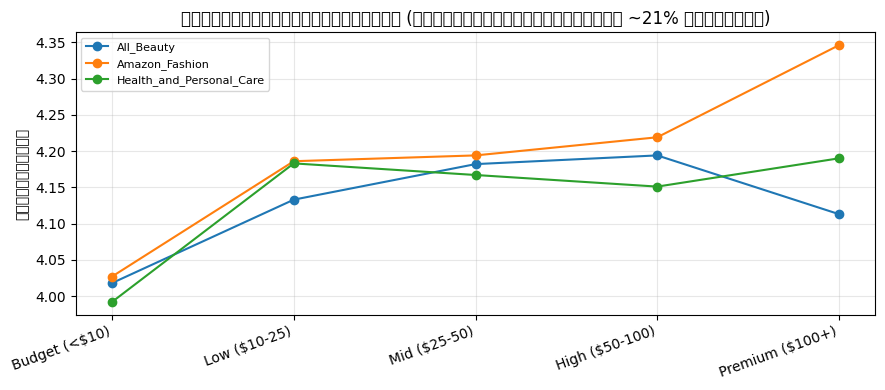

In [5]:
price = con.sql("""
    SELECT p.category, p.price_band,
           count(*) AS n_reviews,
           round(avg(f.rating), 3) AS avg_rating,
           round(avg(f.is_negative::INT), 3) AS negative_share
    FROM fact_review f JOIN dim_product p USING (product_key)
    WHERE p.price_band <> 'Unknown'
    GROUP BY 1, 2
""").df()

order = ["Budget (<$10)", "Low ($10-25)", "Mid ($25-50)", "High ($50-100)", "Premium ($100+)"]
pivot = price.pivot(index="price_band", columns="category", values="avg_rating").reindex(order)
display(pivot.round(3))

pivot.plot(marker="o")
plt.title("คะแนนเฉลี่ยตามช่วงราคา (เฉพาะสินค้าที่รู้ราคา ~21% ของรีวิว)")
plt.ylabel("คะแนนเฉลี่ย"); plt.xlabel("")
plt.xticks(range(len(order)), order, rotation=20, ha="right")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## A3. สินค้าไหนกำลังขาลง?

คะแนนเฉลี่ยรวมขยับช้ามากเพราะถูกถ่วงด้วยรีวิวเก่า สินค้าที่คุณภาพเพิ่งแย่ลงจะยังดูดีอยู่
การเทียบ "ช่วงหลัง vs ก่อนหน้า" ทำให้เห็นปัญหาก่อนคะแนนรวมจะตก

⚠️ ใช้ **2020–2021** เป็นช่วงหลัง ไม่ใช่ 2022+ เพราะปริมาณรีวิวปี 2022–2023
เก็บไม่ครบ (ดูกราฟใน A5)

In [6]:
declining = con.sql("""
    WITH per_product AS (
        SELECT f.product_key,
               avg(f.rating)                                   AS lifetime_avg,
               count(*)                                        AS lifetime_n,
               avg(f.rating) FILTER (WHERE d.year IN (2020, 2021)) AS recent_avg,
               count(*)      FILTER (WHERE d.year IN (2020, 2021)) AS recent_n
        FROM fact_review f JOIN dim_date d USING (date_key)
        GROUP BY f.product_key
    )
    SELECT p.category, p.store,
           substr(p.product_title, 1, 45) AS product,
           pp.lifetime_n, round(pp.lifetime_avg, 2) AS lifetime_avg,
           pp.recent_n,   round(pp.recent_avg, 2)   AS recent_avg,
           round(pp.recent_avg - pp.lifetime_avg, 2) AS delta
    FROM per_product pp JOIN dim_product p USING (product_key)
    WHERE pp.recent_n >= 30 AND pp.lifetime_n >= 100
    ORDER BY delta ASC LIMIT 15
""").df()
declining

,category,store,product,lifetime_n,lifetime_avg,recent_n,recent_avg,delta
0,All_Beauty,GranNaturals,GranNaturals Boar Bristle Smoothing Hair Brus,1362,4.03,105,2.83,-1.20
1,Health_and_Personal_Care,Glade,"Glade Aerosol Air Freshener Lavender Vanilla,",112,3.74,45,2.56,-1.19
2,All_Beauty,Oster,Oster Oster 76-toggle Switch Assembly,146,4.13,34,3.00,-1.13
3,Amazon_Fashion,Rosmax,"Rosmax Backless Strapless Bra,Self Adhesive S",116,3.20,40,2.15,-1.05
4,All_Beauty,Soft 'N Style,"Soft 'N Style Butterfly Clamps, Assorted Colo",507,4.24,43,3.37,-0.87
5,Amazon_Fashion,leawoke,Crazy2Shop Sterling Silver Set of 20 Clear Si,219,3.46,84,2.63,-0.83
6,Health_and_Personal_Care,Tech Love,Tech Love XXL Electric Heating Pad for Neck S,199,4.07,54,3.33,-0.73
7,Health_and_Personal_Care,OMWAH,Beauty Salon Shampoo ABS Plastic Bowl Sink Ha,109,3.74,31,3.03,-0.71
8,All_Beauty,Molecule Scent 01,Molecule Scent 01 - Iso E Super by TRiBUTE8 (,153,3.61,54,2.91,-0.71
9,All_Beauty,Dr. Naylor,Dr. Naylor Udder Balm (36 oz.) - Traditional,146,4.32,42,3.64,-0.67


## A4. รีวิวแบบไหนที่คนบอกว่ามีประโยชน์?

**ใช้ตอบว่า** ควรจัดลำดับรีวิวบนหน้าสินค้าอย่างไร และควรกระตุ้นให้ลูกค้าเขียนแบบไหน

ดู**ค่ามัธยฐาน**ควบคู่ค่าเฉลี่ยเสมอ เพราะการแจกแจงเบ้ขวาหนัก (ส่วนใหญ่ได้ 0 โหวต)

,has_images,length_bucket,n_reviews,avg_helpful,median_helpful,share_with_any_vote
0,False,1. สั้น (<100),1869325,0.23,0.0,0.127
1,True,1. สั้น (<100),61333,1.48,0.0,0.358
2,False,2. กลาง (100-500),1409009,0.76,0.0,0.278
3,True,2. กลาง (100-500),140151,2.56,0.0,0.460
4,False,3. ยาว (500+),142051,3.20,1.0,0.532
5,True,3. ยาว (500+),37067,5.23,1.0,0.590


/var/folders/vn/_y1rl4y52sb3kx0xf36z3zv40000gn/T/ipykernel_7891/1482337408.py:19: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  ax.legend(title="แนบรูป"); plt.xticks(rotation=0); plt.tight_layout(); plt.show()
/var/folders/vn/_y1rl4y52sb3kx0xf36z3zv40000gn/T/ipykernel_7891/1482337408.py:19: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  ax.legend(title="แนบรูป"); plt.xticks(rotation=0); plt.tight_layout(); plt.show()
/var/folders/vn/_y1rl4y52sb3kx0xf36z3zv40000gn/T/ipykernel_7891/1482337408.py:19: UserWarning: Glyph 3657 (\N{THAI CHARACTER MAI THO}) missing from font(s) DejaVu Sans.
  ax.legend(title="แนบรูป"); plt.xticks(rotation=0); plt.tight_layout(); plt.show()
/var/folders/vn/_y1rl4y52sb3kx0xf36z3zv40000gn/T/ipykernel_7891/1482337408.py:19: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  ax.legend(title="แนบรูป"); plt.xticks(rotation=0); plt.tight_layout(

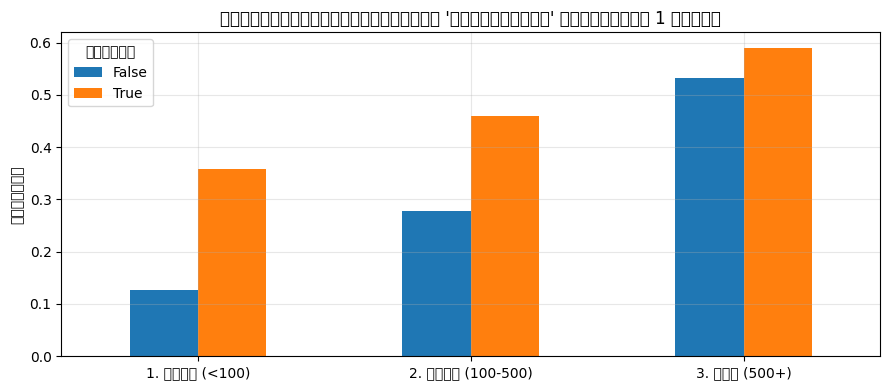

In [7]:
helpful = con.sql("""
    SELECT f.has_images,
           CASE WHEN length(t.review_text) < 100 THEN '1. สั้น (<100)'
                WHEN length(t.review_text) < 500 THEN '2. กลาง (100-500)'
                ELSE                                  '3. ยาว (500+)' END AS length_bucket,
           count(*) AS n_reviews,
           round(avg(f.helpful_vote), 2)            AS avg_helpful,
           median(f.helpful_vote)                   AS median_helpful,
           round(avg((f.helpful_vote > 0)::INT), 3) AS share_with_any_vote
    FROM fact_review f JOIN review_text t USING (review_id)
    GROUP BY 1, 2 ORDER BY 2, 1
""").df()
display(helpful)

ax = helpful.pivot(index="length_bucket", columns="has_images",
                   values="share_with_any_vote").plot(kind="bar")
ax.set_title("สัดส่วนรีวิวที่ได้โหวต 'มีประโยชน์' อย่างน้อย 1 เสียง")
ax.set_ylabel("สัดส่วน"); ax.set_xlabel("")
ax.legend(title="แนบรูป"); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

In [8]:
# helpful_vote มีอคติเรื่องอายุ — รีวิวเก่ามีเวลาสะสมโหวตมากกว่า
# ถ้าไม่คุมตัวแปรนี้ จะสรุปผิดว่า "รีวิวยาวดีกว่า" ทั้งที่จริงแค่ "รีวิวเก่ากว่า"
con.sql("""
    SELECT d.year, count(*) AS n_reviews,
           round(avg(f.helpful_vote), 2) AS avg_helpful,
           round(avg((f.helpful_vote > 0)::INT), 3) AS share_with_any_vote
    FROM fact_review f JOIN dim_date d USING (date_key)
    WHERE d.year BETWEEN 2010 AND 2023
    GROUP BY 1 ORDER BY 1
""").df()

,year,n_reviews,avg_helpful,share_with_any_vote
0,2010,4895,3.12,0.530
1,2011,6934,3.13,0.525
2,2012,14080,2.42,0.473
3,2013,40426,1.68,0.392
4,2014,92315,0.91,0.290
5,2015,196607,0.83,0.249
6,2016,399998,0.97,0.271
7,2017,492961,0.81,0.271
8,2018,489598,0.67,0.217
9,2019,563589,0.63,0.190


## A5. สามหมวดต่างกันแค่ไหน และคะแนนของใครน่าเชื่อถือน้อยที่สุด?

เราจงใจเลือก 3 หมวดที่รวมเป็นหมวดใหญ่เดียวกันได้ ข้อนี้จึงตรวจว่า
"เอามารวมกันวิเคราะห์ได้จริงไหม" — ถ้าสัดส่วน verified หรือความแตกขั้วต่างกันมาก
ห้ามเอาคะแนนข้ามหมวดมาเทียบกันตรง ๆ

In [9]:
cats = con.sql("""
    SELECT f.category,
           count(*) AS n_reviews,
           round(avg(f.rating), 2)                 AS avg_rating,
           round(avg(f.verified_purchase::INT), 3) AS verified_share,
           round(avg((f.rating IN (1, 5))::INT), 3) AS polarized_share,
           round(avg(f.has_images::INT), 4)        AS with_images_share,
           round(avg((u.reviewer_segment = 'One-off')::INT), 3) AS oneoff_share
    FROM fact_review f JOIN dim_user u USING (user_key)
    GROUP BY 1 ORDER BY 2 DESC
""").df()
cats

,category,n_reviews,avg_rating,verified_share,polarized_share,with_images_share,oneoff_share
0,Amazon_Fashion,2475694,3.97,0.935,0.691,0.064,0.842
1,All_Beauty,694252,3.96,0.905,0.745,0.085,0.856
2,Health_and_Personal_Care,488990,4.00,0.901,0.751,0.043,0.884


/var/folders/vn/_y1rl4y52sb3kx0xf36z3zv40000gn/T/ipykernel_7891/98076651.py:18: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/vn/_y1rl4y52sb3kx0xf36z3zv40000gn/T/ipykernel_7891/98076651.py:18: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/vn/_y1rl4y52sb3kx0xf36z3zv40000gn/T/ipykernel_7891/98076651.py:18: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/vn/_y1rl4y52sb3kx0xf36z3zv40000gn/T/ipykernel_7891/98076651.py:18: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/vn/_y1rl4y52sb3kx0xf36z3zv40000gn/T/ipykernel_7891/98076651.py:18: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/v

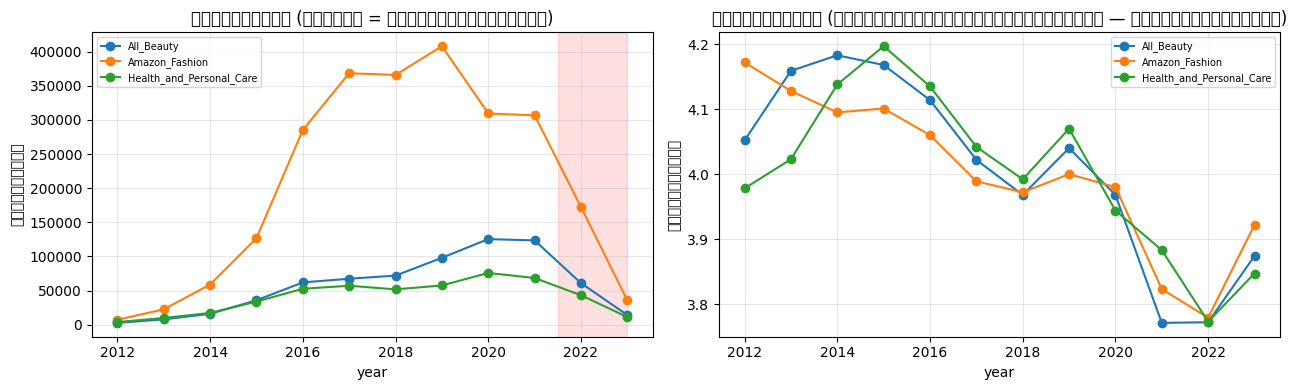

In [10]:
# ปริมาณรีวิวรายปี — เห็นชัดว่าปี 2022-2023 เก็บไม่ครบ ห้ามอ่านเป็น "ดีมานด์หด"
trend = con.sql("""
    SELECT d.year, f.category, count(*) AS n_reviews, round(avg(f.rating), 3) AS avg_rating
    FROM fact_review f JOIN dim_date d USING (date_key)
    WHERE d.year BETWEEN 2012 AND 2023
    GROUP BY 1, 2 ORDER BY 1
""").df()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
trend.pivot(index="year", columns="category", values="n_reviews").plot(ax=ax1, marker="o")
ax1.axvspan(2021.5, 2023, color="red", alpha=0.12)
ax1.set_title("จำนวนรีวิว (แถบแดง = ข้อมูลเก็บไม่ครบ)")
ax1.set_ylabel("จำนวนรีวิว"); ax1.legend(fontsize=7)

trend.pivot(index="year", columns="category", values="avg_rating").plot(ax=ax2, marker="o")
ax2.set_title("คะแนนเฉลี่ย (ตัวชี้วัดที่ไม่ขึ้นกับจำนวน — ใช้ดูแนวโน้มได้)")
ax2.set_ylabel("คะแนนเฉลี่ย"); ax2.legend(fontsize=7)
plt.tight_layout(); plt.show()

## สรุปสิ่งที่ได้

รันแล้วจะเห็นว่า:

- **A1** แบรนด์ที่รีวิวเยอะแต่คะแนนต่ำน่าสนใจกว่าอันดับต้น เพราะกระทบลูกค้าจำนวนมาก
- **A2** คะแนนมีแนวโน้มเพิ่มตามช่วงราคา แต่ข้อสรุปนี้อ้างได้เฉพาะสินค้าที่รู้ราคา (~21%)
  ซึ่งเป็นกลุ่มที่คะแนนสูงกว่าค่าเฉลี่ยอยู่แล้ว
- **A3** ได้รายชื่อสินค้าที่คะแนนช่วงหลังตกจากค่าเฉลี่ยตลอดชีพ → ส่งทีมตรวจสอบ
- **A4** รีวิวยาวและมีรูปได้โหวตมากกว่า แต่ต้องคุมอคติเรื่องอายุรีวิวก่อนสรุป
- **A5** ทั้ง 3 หมวดมี verified สูงใกล้เคียงกัน (90–94%) เทียบข้ามหมวดได้พอสมควร

ขั้นต่อไป — คำถามที่ต้องใช้โมเดล อยู่ที่ [`../model/model.ipynb`](../model/model.ipynb)

In [11]:
con.close()
print("analytics เสร็จเรียบร้อย")

analytics เสร็จเรียบร้อย
